# 9.1. Perspectivas cuantitativas para Black-Litterman con PyPortfolioOpt

En este cuaderno construiremos una versión aplicada del modelo de Black-Litterman usando datos reales de Yahoo Finance y la librería `PyPortfolioOpt`.
[(Descargar diapositivas )](5_1_perspectivas.pdf)

Si quieres ampliar el concepto de redes neuronales para series de tiempo puedes ver las dipositivas: [(Descargar diapositivas series de tiempo)](Redes_para_series.pdf)


## Objetivos

1. Descargar precios históricos de un conjunto de ETFs desde Yahoo Finance.
2. Estimar la distribución previa del mercado usando capitalizaciones aproximadas y la matriz de covarianzas.
3. Generar visiones cuantitativas sobre los activos con dos enfoques de pronóstico:
   - un modelo ARCH-GARCH,
   - una red neuronal LSTM.
4. Automatizar la construcción de las matrices $P$, $Q$ y $\Omega$.
5. Obtener los retornos posteriores del modelo de Black-Litterman y un portafolio resultante.

La idea central es que las visiones no se escriben manualmente, sino que se producen a partir de señales pronosticadas con modelos de series de tiempo.

## Flujo del ejercicio

Trabajaremos con el universo `SPY`, `QQQ`, `IEF`, `GLD` y `VNQ`.

- `SPY` representa una aproximación al mercado accionario amplio y nos servirá para inferir la aversión al riesgo del mercado.
- `QQQ`, `IEF` y `GLD` serán los activos sobre los que construiremos visiones cuantitativas.
- `VNQ` se mantiene en el universo para observar cómo cambia la asignación posterior del portafolio.

Las visiones se expresarán a un horizonte de 21 días hábiles y luego se anualizarán para que sean comparables con los retornos implícitos del modelo.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from arch import arch_model
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from pypfopt import black_litterman, risk_models
from pypfopt.black_litterman import BlackLittermanModel
from pypfopt.efficient_frontier import EfficientFrontier

np.random.seed(42)
tf.keras.utils.set_random_seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format

In [2]:
tickers = ["SPY", "QQQ", "IEF", "GLD", "VNQ"]
view_assets = ["QQQ", "IEF", "GLD"]
start_date = "2020-01-01"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")
horizon = 21
tau = 0.05

raw_prices = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
)

if isinstance(raw_prices.columns, pd.MultiIndex):
    prices = raw_prices["Close"].dropna(how="all")
else:
    prices = raw_prices.copy()
    if "Close" in prices.columns:
        prices = prices[["Close"]]
        prices.columns = tickers[:1]

prices = prices.dropna()
returns = prices.pct_change().dropna()


def yahoo_market_size(ticker):
    fallback_sizes = {
        "SPY": 550e9,
        "QQQ": 320e9,
        "IEF": 35e9,
        "GLD": 65e9,
        "VNQ": 35e9,
    }

    ticker_obj = yf.Ticker(ticker)
    size_candidates = []

    try:
        fast_info = getattr(ticker_obj, "fast_info", {})
        if hasattr(fast_info, "get"):
            size_candidates.append(fast_info.get("market_cap"))
    except Exception:
        pass

    try:
        info = ticker_obj.info
        size_candidates.extend(
            [
                info.get("marketCap"),
                info.get("totalAssets"),
                info.get("enterpriseValue"),
            ]
        )
    except Exception:
        pass

    return float(
        next(
            (
                value
                for value in size_candidates
                if value is not None and pd.notna(value) and value > 0
            ),
            fallback_sizes[ticker],
        )
    )


market_caps = pd.Series(
    {ticker: yahoo_market_size(ticker) for ticker in tickers},
    name="tamano_mercado_proxy",
)

print(f"Muestra de precios desde {prices.index.min().date()} hasta {prices.index.max().date()}")
display(prices.tail())
display((market_caps / 1e9).rename("USD miles de millones"))

Muestra de precios desde 2020-01-02 hasta 2026-03-18


Ticker,GLD,IEF,QQQ,SPY,VNQ
Date,,,,,
2026-03-12,466.8800,95.6900,597.2600,666.0600,92.0100
2026-03-13,460.8400,95.5900,593.7200,662.2900,92.1600
2026-03-16,460.4300,96.0200,600.3800,669.0300,92.9300
2026-03-17,459.2700,96.1900,603.3100,670.7900,93.3400
2026-03-18,444.7400,95.7500,594.9000,661.4300,91.9600


SPY   602.7075
QQQ   231.8347
IEF    13.9507
GLD   110.1538
VNQ    33.7883
Name: USD miles de millones, dtype: float64

## Paso 1. Distribución previa implícita del mercado


Usaremos:

- la covarianza muestral anualizada de los precios,
- una proxy del tamaño de mercado obtenida desde Yahoo Finance,
- la serie de `SPY` para estimar la aversión al riesgo del mercado.

Con esto obtenemos el vector previo $\pi$ antes de incorporar las visiones.

In [3]:
cov_matrix = risk_models.sample_cov(prices, frequency=252)
market_prices = prices["SPY"]
delta = black_litterman.market_implied_risk_aversion(market_prices)
pi = black_litterman.market_implied_prior_returns(
    market_caps.to_dict(),
    delta,
    cov_matrix,
)

prior_table = pd.DataFrame(
    {
        "peso_mercado": market_caps / market_caps.sum(),
        "retorno_implícito_anual": pi,
    }
).sort_values("peso_mercado", ascending=False)

print(f"Aversión al riesgo implícita del mercado (delta): {delta:,.4f}")
display(prior_table)

Aversión al riesgo implícita del mercado (delta): 3.5658


,peso_mercado,retorno_implícito_anual
SPY,0.6073,0.1377
QQQ,0.2336,0.1636
GLD,0.1110,0.0285
VNQ,0.0340,0.1237
IEF,0.0141,-0.0013


## Paso 2. Pronóstico de visiones con ARCH-GARCH y LSTM

Ahora construiremos las visiones de manera cuantitativa.

Para cada activo seleccionado estimaremos un retorno esperado a 21 días con dos modelos:

- un modelo `ARCH-GARCH` para capturar persistencia de varianza y dinámica lineal del retorno medio,
- una `LSTM` para capturar patrones no lineales en la serie de retornos.

La visión final de cada activo se construirá con el promedio de ambos pronósticos. Luego convertiremos ese retorno de 21 días a una tasa anual equivalente para alimentar el modelo de Black-Litterman.

In [4]:
def compound_returns(daily_returns):
    return float(np.prod(1 + np.asarray(daily_returns)) - 1)


def annualize_horizon_return(period_return, horizon=21):
    return float((1 + period_return) ** (252 / horizon) - 1)


def garch_view_forecast(series, horizon=21):
    clean_series = series.dropna().astype(float)
    scaled_series = clean_series * 100

    model = arch_model(
        scaled_series,
        mean="AR",
        lags=1,
        vol="GARCH",
        p=1,
        q=1,
        dist="normal",
        rescale=False,
    )
    result = model.fit(disp="off")
    forecast = result.forecast(horizon=horizon, reindex=False)

    daily_mean = forecast.mean.iloc[-1].to_numpy() / 100
    daily_variance = forecast.variance.iloc[-1].to_numpy() / 10000

    return {
        "forecast_21d": compound_returns(daily_mean),
        "volatility_21d": float(np.sqrt(np.sum(daily_variance))),
        "model": result,
    }


def make_sequences(values, lookback):
    X, y = [], []
    for idx in range(lookback, len(values)):
        X.append(values[idx - lookback:idx])
        y.append(values[idx])
    return np.asarray(X), np.asarray(y)


def lstm_view_forecast(series, lookback=20, horizon=21, epochs=20):
    clean_series = series.dropna().astype(float)
    scaler = MinMaxScaler()
    scaled_values = scaler.fit_transform(clean_series.to_numpy().reshape(-1, 1))

    X, y = make_sequences(scaled_values, lookback)
    split_idx = int(len(X) * 0.8)

    X_train, X_val = X[:split_idx], X[split_idx:]
    y_train, y_val = y[:split_idx], y[split_idx:]

    model = keras.Sequential(
        [
            layers.Input(shape=(lookback, 1)),
            layers.LSTM(24),
            layers.Dense(12, activation="relu"),
            layers.Dense(1),
        ]
    )
    model.compile(optimizer="adam", loss="mse")

    callbacks = [keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
    model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=16,
        verbose=0,
        callbacks=callbacks,
    )

    recursive_window = scaled_values[-lookback:].reshape(1, lookback, 1)
    future_scaled = []

    for _ in range(horizon):
        next_scaled = model.predict(recursive_window, verbose=0)[0, 0]
        future_scaled.append(next_scaled)
        next_step = np.array([[[next_scaled]]])
        recursive_window = np.concatenate([recursive_window[:, 1:, :], next_step], axis=1)

    future_returns = scaler.inverse_transform(np.array(future_scaled).reshape(-1, 1)).ravel()
    val_predictions = scaler.inverse_transform(model.predict(X_val, verbose=0)).ravel()
    val_true = scaler.inverse_transform(y_val.reshape(-1, 1)).ravel()

    return {
        "forecast_21d": compound_returns(future_returns),
        "rmse": float(np.sqrt(mean_squared_error(val_true, val_predictions))),
        "model": model,
    }

,garch_21d,lstm_21d,vision_21d,vision_anual,confianza,volatilidad_garch_21d,rmse_lstm
activo,,,,,,,
QQQ,0.0230,-0.0909,-0.0340,-0.3397,0.2500,0.0587,0.0146
IEF,0.0002,-0.0020,-0.0009,-0.0109,0.8141,0.0170,0.0035
GLD,0.0102,0.0375,0.0239,0.3275,0.7545,0.0664,0.0153


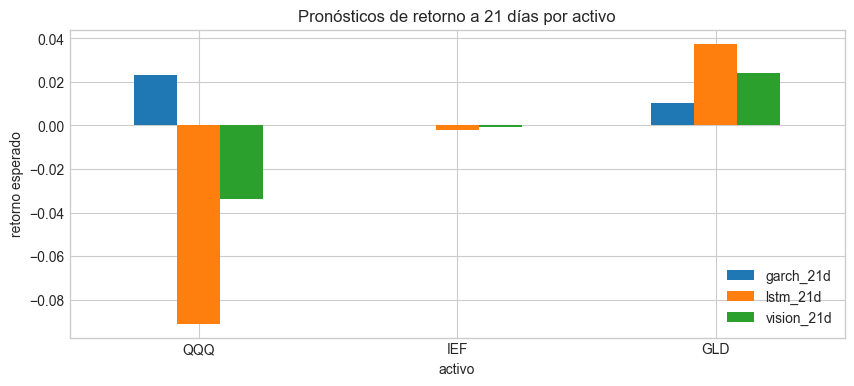

In [6]:
forecast_store = {}
forecast_rows = []

for asset in view_assets:
    garch_output = garch_view_forecast(returns[asset], horizon=horizon)
    lstm_output = lstm_view_forecast(returns[asset], horizon=horizon, epochs=20)

    blended_21d = 0.5 * (garch_output["forecast_21d"] + lstm_output["forecast_21d"])
    blended_annual = annualize_horizon_return(blended_21d, horizon=horizon)

    disagreement = abs(garch_output["forecast_21d"] - lstm_output["forecast_21d"])
    horizon_vol = returns[asset].rolling(63).std().iloc[-1] * np.sqrt(horizon)
    confidence = float(np.clip(1 - disagreement / (horizon_vol + 1e-6), 0.25, 0.85))

    forecast_store[asset] = {
        "garch": garch_output,
        "lstm": lstm_output,
        "blended_21d": blended_21d,
        "blended_annual": blended_annual,
        "confidence": confidence,
    }

    forecast_rows.append(
        {
            "activo": asset,
            "garch_21d": garch_output["forecast_21d"],
            "lstm_21d": lstm_output["forecast_21d"],
            "vision_21d": blended_21d,
            "vision_anual": blended_annual,
            "confianza": confidence,
            "volatilidad_garch_21d": garch_output["volatility_21d"],
            "rmse_lstm": lstm_output["rmse"],
        }
    )

forecast_table = pd.DataFrame(forecast_rows).set_index("activo")
display(forecast_table)

ax = forecast_table[["garch_21d", "lstm_21d", "vision_21d"]].plot(
    kind="bar",
    figsize=(10, 4),
    title="Pronósticos de retorno a 21 días por activo",
)
ax.set_ylabel("retorno esperado")
plt.xticks(rotation=0)
plt.show()

## Paso 3. Automatización de $P$, $Q$ y $\Omega$

Recordemos el significado de estas matrices en Black-Litterman:

- $P$ indica cómo cada visión se conecta con los activos del universo.
- $Q$ contiene el retorno esperado de cada visión.
- $\Omega$ representa la incertidumbre de las visiones.

En vez de escribir estas matrices manualmente, construiremos una tabla estructurada de visiones y luego dejaremos que `PyPortfolioOpt` genere $\Omega$ con el esquema de `Idzorek` a partir de niveles de confianza. Así, la incertidumbre queda automatizada y consistente con las señales pronosticadas.

In [7]:
view_specs = [
    {
        "nombre": "QQQ absoluto",
        "weights": {"QQQ": 1.0},
        "q": forecast_store["QQQ"]["blended_annual"],
        "confidence": forecast_store["QQQ"]["confidence"],
    },
    {
        "nombre": "GLD absoluto",
        "weights": {"GLD": 1.0},
        "q": forecast_store["GLD"]["blended_annual"],
        "confidence": forecast_store["GLD"]["confidence"],
    },
    {
        "nombre": "QQQ menos IEF",
        "weights": {"QQQ": 1.0, "IEF": -1.0},
        "q": forecast_store["QQQ"]["blended_annual"] - forecast_store["IEF"]["blended_annual"],
        "confidence": float(
            np.clip(
                0.5 * (
                    forecast_store["QQQ"]["confidence"]
                    + forecast_store["IEF"]["confidence"]
                ),
                0.25,
                0.85,
            )
        ),
    },
]


def build_view_matrices(assets, view_specs):
    labels = [view["nombre"] for view in view_specs]
    P = pd.DataFrame(0.0, index=labels, columns=assets)
    Q = pd.Series(index=labels, dtype=float, name="Q")
    confidences = pd.Series(index=labels, dtype=float, name="confianza")

    for view in view_specs:
        label = view["nombre"]
        for asset, weight in view["weights"].items():
            P.loc[label, asset] = weight
        Q.loc[label] = view["q"]
        confidences.loc[label] = view["confidence"]

    return P, Q, confidences


P, Q, view_confidences = build_view_matrices(tickers, view_specs)

bl = BlackLittermanModel(
    cov_matrix,
    pi=pi,
    P=P.values,
    Q=Q.values,
    omega="idzorek",
    view_confidences=view_confidences.values,
    tau=tau,
)

omega = pd.DataFrame(bl.omega, index=P.index, columns=P.index)

print("Matriz P")
display(P)
print("Vector Q")
display(Q.to_frame())
print("Confianzas usadas para Idzorek")
display(view_confidences.to_frame())
print("Matriz Omega resultante")
display(omega)

Matriz P


,SPY,QQQ,IEF,GLD,VNQ
QQQ absoluto,0.0000,1.0000,0.0000,0.0000,0.0000
GLD absoluto,0.0000,0.0000,0.0000,1.0000,0.0000
QQQ menos IEF,0.0000,1.0000,-1.0000,0.0000,0.0000


Vector Q


,Q
QQQ absoluto,-0.3397
GLD absoluto,0.3275
QQQ menos IEF,-0.3288


Confianzas usadas para Idzorek


,confianza
QQQ absoluto,0.2500
GLD absoluto,0.7545
QQQ menos IEF,0.5321


Matriz Omega resultante


,QQQ absoluto,GLD absoluto,QQQ menos IEF
QQQ absoluto,0.0009,0.0000,0.0000
GLD absoluto,0.0000,0.0007,0.0000
QQQ menos IEF,0.0000,0.0000,0.0031


## Paso 4. Retornos posteriores y portafolio resultante

Una vez combinamos la distribución previa con las visiones, obtenemos un nuevo vector de retornos esperados y una nueva matriz de covarianzas.

A partir de estos parámetros posteriores podemos resolver un problema clásico de optimización de portafolios para observar cómo cambian los pesos recomendados.

,prior,posterior,cambio_bp
Ticker,,,
QQQ,0.1636,0.3025,"1,389.5289"
SPY,0.1377,0.2738,"1,360.7948"
VNQ,0.1237,0.2201,964.3321
GLD,0.0285,-0.0110,-395.3175
IEF,-0.0013,-0.0849,-835.8591


,peso
SPY,0.5000
QQQ,0.4205
VNQ,0.0795


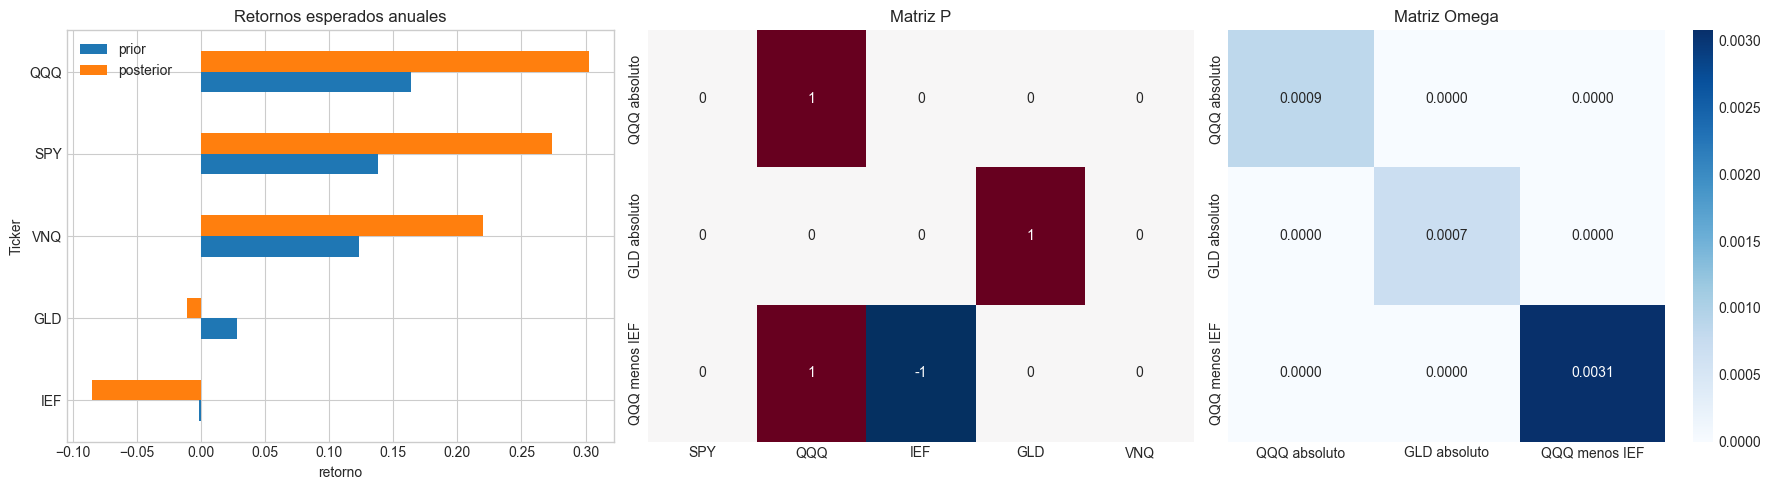

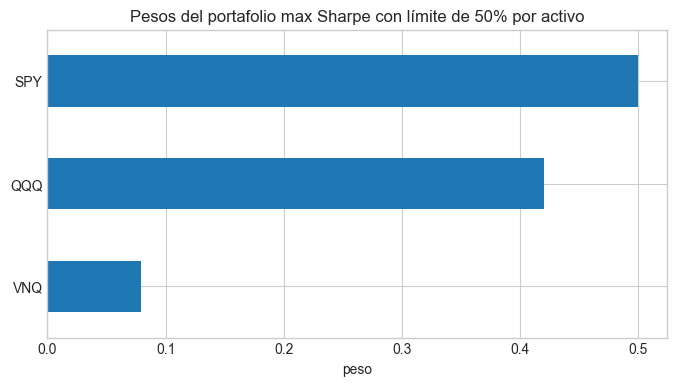

In [9]:
posterior_returns = bl.bl_returns()
posterior_cov = bl.bl_cov()

comparison = pd.DataFrame(
    {
        "prior": pi,
        "posterior": posterior_returns,
        "cambio_bp": (posterior_returns - pi) * 10_000,
    }
).sort_values("posterior", ascending=False)

display(comparison)

ef = EfficientFrontier(
    posterior_returns,
    posterior_cov,
    weight_bounds=(0.0, 0.50),
)
ef.max_sharpe(risk_free_rate=0.0)
weights = pd.Series(ef.clean_weights(), name="peso")
weights = weights[weights.abs() > 0]
display(weights.sort_values(ascending=False).to_frame())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

comparison[["prior", "posterior"]].sort_values("posterior").plot(
    kind="barh",
    ax=axes[0],
    title="Retornos esperados anuales",
)
axes[0].set_xlabel("retorno")

sns.heatmap(P, annot=True, cmap="RdBu_r", center=0, cbar=False, ax=axes[1])
axes[1].set_title("Matriz P")

sns.heatmap(omega, annot=True, fmt=".4f", cmap="Blues", ax=axes[2])
axes[2].set_title("Matriz Omega")

plt.tight_layout()
plt.show()

weights.sort_values().plot(
    kind="barh",
    figsize=(8, 4),
    title="Pesos del portafolio max Sharpe con límite de 50% por activo",
)
plt.xlabel("peso")
plt.show()

## Lectura económica de los resultados

- Si una visión tiene alta confianza, su efecto en los retornos posteriores será mayor y el correspondiente elemento diagonal de $\Omega$ será menor.
- Si dos modelos de pronóstico discrepan mucho, la confianza asignada cae y la visión pesa menos dentro de Black-Litterman.
- La matriz $P$ permite mezclar visiones absolutas y relativas sin cambiar la lógica del flujo.

Este enfoque es útil cuando se desea conectar modelos predictivos con asignación táctica de portafolios de una forma sistemática y reproducible.

## Taller de clase: Black-Litterman con matriz de perspectivas modelada

### Objetivo del taller

Diseñar y justificar un portafolio con el modelo de Black-Litterman donde la matriz de perspectivas se construya a partir de pronósticos cuantitativos.

Cada equipo debe elegir una de estas dos rutas:

- `Ruta A (retornos)`: el modelo pronostica retornos esperados de los activos.
- `Ruta B (volatilidad)`: el modelo pronostica volatilidad y ustedes traducen esa señal a perspectivas de retorno relativo o absoluto con una regla explícita.

Pueden usar el modelo que prefieran: ARIMA, Prophet, GARCH, LSTM, XGBoost, Random Forest, etc.

### Requisitos mínimos

1. Elegir 4 activos entre los que ya vienen trabajando (acciones o ETFs) y descargar datos de Yahoo Finance.
2. Construir la distribución previa del mercado ($\pi$) con `PyPortfolioOpt`.
3. Definir al menos 3 visiones, con al menos:
   - una visión absoluta,
   - una visión relativa (activo A vs activo B).
4. Construir explícitamente $P$, $Q$ y los niveles de confianza por visión.
5. Generar $\Omega$ de forma consistente (por ejemplo con `idzorek`).
6. Obtener retornos posteriores y resolver un portafolio óptimo.
7. Comparar resultados contra un benchmark (igual ponderado o market-cap proxy).

### Preguntas guía para el reporte

- ¿Por qué eligieron ese modelo de pronóstico?
- ¿Cómo transformaron el pronóstico en una visión de Black-Litterman?
- ¿Cómo definieron la confianza de cada visión?
- ¿Qué activos ganan y cuáles pierden peso frente al apriori?
- ¿Qué tan sensible es el resultado si cambian $\tau$ o las confianzas?

### Entregables

- Tabla final con $P$, $Q$, confianzas y $\Omega$.
- Gráfico de pesos del portafolio posterior.
- Conclusiones 